# Netflix Data Analysis
Authors: Alex Arce, Lunden Mandigo, Tyrone Pettygrue 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')

In [4]:
imdb_movies = pd.read_csv('merged_movie_imdb.csv')
box_office = pd.read_csv('enhanced_box_office_data(2000-2024)u.csv')


## Data Collection and Merging
We collected the IMDB movie data from the [IMDB Developer page] (https://developer.imdb.com/non-commercial-datasets/), which provides non-commercial access to a vareity of datasets. For our project, we downloaded "title.basics.tsv.gz" and "title.ratings.tsv.gz". These .tsv files were decompressed using gunzip and loaded into our repository. We quickly realized that these files are way too big to store in GitHub. We merged the files locally on the column "tconst". A full description of columns is written below. After merging, we narrowed our project scope to the years 2001-2025. This decreased the size of the data and allowed us to store the data in GitHub.

We also collected Box Office data from a highly rated [kaggle dataset] (https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024?resource=download). This data provides information related to movie revenue, such as production cost and worldwide earnings.

The IMDB movie data and box office data will be merged on the title of the film, which is represented as a 'primaryTitle' feature in the IMDB data and 'release group' feature in the box office data.



## Data Description

**title.basics**
- tconst (string) - alphanumeric unique identifier of the title
- titleType (string) – the type/format of the title (e.g. movie, short, tvseries, tvepisode, video, etc)
- primaryTitle (string) – the more popular title / the title used by the filmmakers on promotional materials at the point of release
- originalTitle (string) - original title, in the original language
- isAdult (boolean) - 0: non-adult title; 1: adult title
- startYear (YYYY) – represents the release year of a title. In the case of TV Series, it is the series start year
- endYear (YYYY) – TV Series end year. '\N' for all other title types
- runtimeMinutes – primary runtime of the title, in minutes
- genres (string array) – includes up to three genres associated with the title

**title.ratings**
- tconst (string) - alphanumeric unique identifier of the title
- averageRating – weighted average of all the individual user ratings
- numVotes - number of votes the title has received

**Merged imdb_movies**
- tconst (string) - alphanumeric unique identifier of the title
- titleType (string) – the type/format of the title (e.g. movie, short, tvseries, tvepisode, video, etc)
- primaryTitle (string) – the more popular title / the title used by the filmmakers on promotional materials at the point of release
- originalTitle (string) - original title, in the original language
- isAdult (boolean) - 0: non-adult title; 1: adult title
- startYear (YYYY) – represents the release year of a title. In the case of TV Series, it is the series start year
- endYear (YYYY) – TV Series end year. '\N' for all other title types
- runtimeMinutes – primary runtime of the title, in minutes
- genres (string array) – includes up to three genres associated with the title
- averageRating – weighted average of all the individual user ratings
- numVotes - number of votes the title has received

**enhanced_box_office_data(2000-2024)u**
- Rank - The global ranking of the movie based on worldwide box office revenue.
- Release Group - The title of the movie or film series.
- $Worldwide - Total worldwide box office revenue for the movie
- $Domestic - Total domestic (local) box office revenue.
- Domestic % - Percentage of worldwide revenue generated domestically.
- $Foreign - Total foreign (international) box office revenue.
- Foreign % - Percentage of worldwide revenue generated in foreign markets.
- Year - The release year of the movie.
- Genres - The genres associated with the movie (e.g., Action, Drama, Comedy).
- Rating - Average audience rating from TMDB (e.g., 7.5/10).
- Vote_Count - The number of votes the movie received on TMDB.
- Original_Language - The primary language of the movie.
- Production_Countires - The countries where the movie was produced.


**IMDB Movies**

In [5]:
print(imdb_movies.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188554 entries, 0 to 188553
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      188554 non-null  int64  
 1   tconst          188554 non-null  object 
 2   titleType       188554 non-null  object 
 3   primaryTitle    188553 non-null  object 
 4   originalTitle   188553 non-null  object 
 5   isAdult         188554 non-null  int64  
 6   startYear       188554 non-null  int64  
 7   endYear         188554 non-null  object 
 8   runtimeMinutes  188554 non-null  object 
 9   genres          188554 non-null  object 
 10  averageRating   188554 non-null  float64
 11  numVotes        188554 non-null  int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 17.3+ MB
None


In [6]:
imdb_movies.sample(5)

,Unnamed: 0,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
180245,1478816,tt8498366,movie,Melrose,Melrose,0,2018,\N,105,"Comedy,Crime,Drama",5.0,59
101873,977406,tt2350608,movie,Revolution,Revolution,0,2012,\N,85,"Adventure,Documentary,Family",7.3,466
136017,1193047,tt3636326,movie,Soul Boys of the Western World,Soul Boys of the Western World,0,2014,\N,110,"Biography,Documentary,Music",6.9,630
167727,1395535,tt6794790,movie,Os caminhos de Che: Um Diário de Motocicleta,Os caminhos de Che: Um Diário de Motocicleta,0,2007,\N,\N,Documentary,5.7,10
182629,1495052,tt8892444,movie,Red Room,Red Room,0,2019,\N,116,"Drama,Thriller",5.0,64


In [7]:
# rename columns
imdb_movies.rename(columns={'primaryTitle':'title'}, inplace=True)
box_office.rename(columns={'Release Group':'title'}, inplace=True)

# merge the two dataframes
movies = pd.merge(imdb_movies, box_office, on='title', how='inner')

# remove unnecessary columns (Unnamed: 0, tconst, titleType, endYear, startYear, Genres, Rating, Vote_Count
movies.drop(columns=['Unnamed: 0', 'tconst', 'titleType', 'endYear', 'startYear', 'Genres', 'Rating', 'Vote_Count'], inplace=True)

# Rename columns for usability
movies.rename(columns={'averageRating': 'IMDBavgRating', 'Rank': 'rank', "$Worldwide": 'worldwideGross', "$Domestic": 'domesticGross', 'Domestic %': "domestic%", "$Foreign": 'foreignGross', 'Foreign %': 'foreign%', 'Year': 'year', 'Original_Language': 'originalLang', 'Production_Countries': 'productionCountries'}, inplace=True)

# remove movies from before 2001
movies = movies[movies['year'] >= 2001]

movies.head(5)

,title,originalTitle,isAdult,runtimeMinutes,genres,IMDBavgRating,numVotes,rank,worldwideGross,domesticGross,domestic%,foreignGross,foreign%,year,originalLang,productionCountries
0,Kate & Leopold,Kate & Leopold,0,118,"Comedy,Fantasy,Romance",6.4,91304,56,76019048.0,47121859.0,62.0,28897189.0,38.0,2001,en,United States of America
1,The Sorcerer's Apprentice,The Sorcerer's Apprentice,0,86,"Adventure,Family,Fantasy",4.2,757,34,215283742.0,63150991.0,29.3,152132751.0,70.7,2010,en,United States of America
2,Fantastic Four,Fantastic Four,0,106,"Action,Adventure,Fantasy",5.7,353227,11,333535934.0,154696080.0,46.4,178839854.0,53.6,2005,en,"Germany, United States of America"
3,Fantastic Four,Fantastic Four,0,106,"Action,Adventure,Fantasy",5.7,353227,44,167882881.0,56117548.0,33.4,111765333.0,66.6,2015,en,"United Kingdom, Germany, United States of America"
4,Frida,Frida,0,123,"Biography,Drama,Romance",7.3,97408,78,56298474.0,25885000.0,46.0,30413474.0,54.0,2002,en,"Canada, Mexico, United States of America"


In [8]:
movies.columns


Index(['title', 'originalTitle', 'isAdult', 'runtimeMinutes', 'genres',
       'IMDBavgRating', 'numVotes', 'rank', 'worldwideGross', 'domesticGross',
       'domestic%', 'foreignGross', 'foreign%', 'year', 'originalLang',
       'productionCountries'],
      dtype='object')

In [9]:

# There are 36 rows that have a missing value in genre column
movies['genres'].str.contains(r'\\N').value_counts()

# Replace these values with None
movies[movies['genres'].str.contains(r'\\N')]
movies = movies[movies['genres'] != '\\N']
movies.shape


(7004, 16)

In [10]:
# Create new column for main genre
movies['main_genre'] = movies['genres'].str.split(',').str[0]

# Checking if new column is created
movies

,title,originalTitle,isAdult,runtimeMinutes,genres,IMDBavgRating,numVotes,rank,worldwideGross,domesticGross,domestic%,foreignGross,foreign%,year,originalLang,productionCountries,main_genre
0,Kate & Leopold,Kate & Leopold,0,118,"Comedy,Fantasy,Romance",6.4,91304,56,7.601905e+07,47121859.0,62.0,28897189.0,38.0,2001,en,United States of America,Comedy
1,The Sorcerer's Apprentice,The Sorcerer's Apprentice,0,86,"Adventure,Family,Fantasy",4.2,757,34,2.152837e+08,63150991.0,29.3,152132751.0,70.7,2010,en,United States of America,Adventure
2,Fantastic Four,Fantastic Four,0,106,"Action,Adventure,Fantasy",5.7,353227,11,3.335359e+08,154696080.0,46.4,178839854.0,53.6,2005,en,"Germany, United States of America",Action
3,Fantastic Four,Fantastic Four,0,106,"Action,Adventure,Fantasy",5.7,353227,44,1.678829e+08,56117548.0,33.4,111765333.0,66.6,2015,en,"United Kingdom, Germany, United States of America",Action
4,Frida,Frida,0,123,"Biography,Drama,Romance",7.3,97408,78,5.629847e+07,25885000.0,46.0,30413474.0,54.0,2002,en,"Canada, Mexico, United States of America",Biography
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7138,Moonage Daydream,Moonage Daydream,0,135,"Biography,Documentary,History",7.6,15578,145,1.309578e+07,4218925.0,32.2,8876856.0,67.8,2022,en,"Germany, United States of America",Biography
7139,Kiss Kiss Bang Bang,Kiss Kiss Bang Bang,0,98,"Crime,Romance,Thriller",3.2,7,191,1.578515e+07,4243756.0,26.9,11541392.0,73.1,2005,en,United States of America,Crime
7140,Aladdin,Aladdin,0,104,"Drama,Musical,Romance",5.1,51,9,1.050694e+09,355559216.0,33.8,695134737.0,66.2,2019,en,United States of America,Drama
7141,Unstoppable,Unstoppable,0,84,Documentary,7.8,23,43,1.678055e+08,81562942.0,48.6,86242524.0,51.4,2010,en,"United Kingdom, United States of America",Documentary


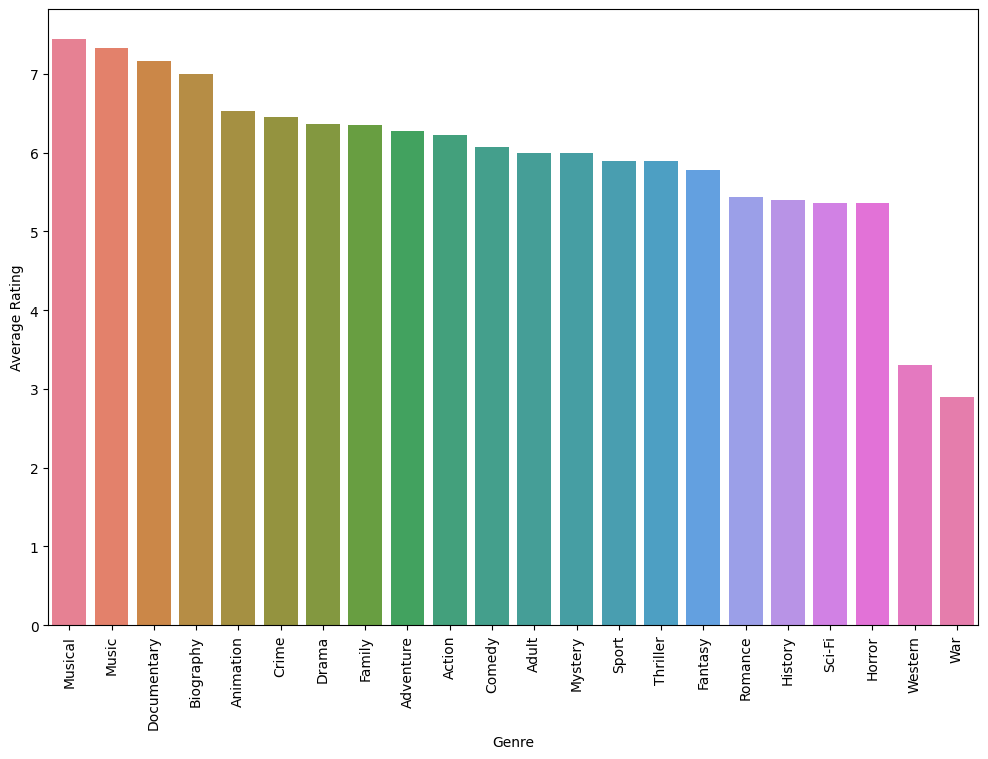

In [11]:
# Need to do a groupby for genre
main_genre_grouped = movies.groupby('main_genre')['IMDBavgRating'].mean().reset_index()



# Sorting rating from highest to lowest
main_genre_grouped = main_genre_grouped.sort_values('IMDBavgRating', ascending=False)

# Creation of visualization for highest rated genres 
fig, ax = plt.subplots(figsize=(12,8))
sns.barplot(x=main_genre_grouped['main_genre'], y=main_genre_grouped['IMDBavgRating'], hue=main_genre_grouped['main_genre'], ax=ax, label='Average Rating by main genre')
ax.set_xlabel("Genre")
ax.set_ylabel("Average Rating")
plt.xticks(rotation=90)
plt.show()

## Results
- The Genres with the highest average ratings are Musical, Music and Documentaries.
- We filtered the data to find the main genre for each movie in our DataFrame as some films have multiple genres (Romance,Comedy).

### Finding the Top 5 Film that are over the average runtime and over 10,000 votes

In [12]:
# Replacing all 'N' in runtimeMinutes to 0
movies.loc[
    movies['runtimeMinutes'].str.contains('N', na=False), 'runtimeMinutes'
] = 0




# Converting the dtype of runtimeMinutes to int
movies['runtimeMinutes'] = movies['runtimeMinutes'].astype('int')





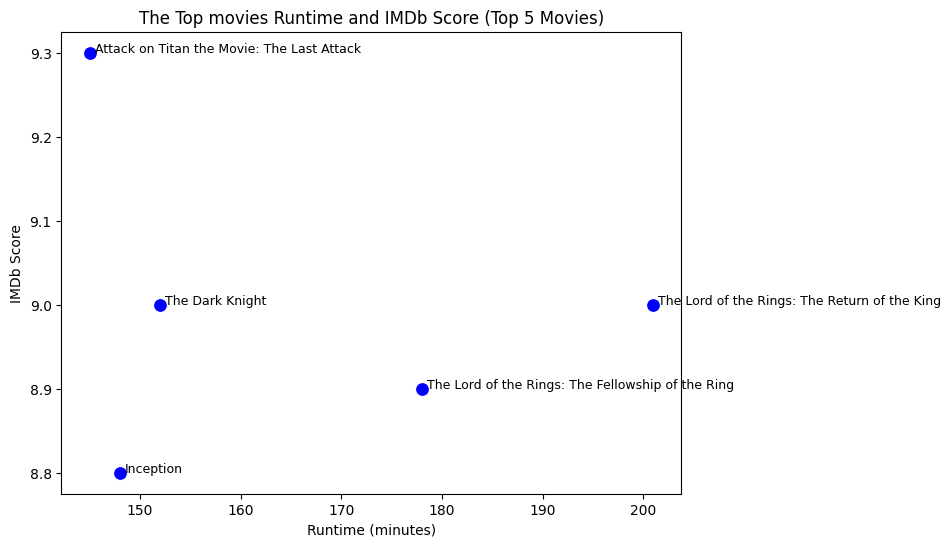

In [13]:
# Filter for the top 5 movies by 'averageRating' and have over 10000 votes and over 120 minutes long
top5_movies = movies[
    (movies['runtimeMinutes'] > 120) &
    (movies['numVotes'] > 10000)
].sort_values('IMDBavgRating', ascending=False).head(5)



plt.figure(figsize=(8,6))
ax = sns.scatterplot(data=top5_movies, x='runtimeMinutes', y='IMDBavgRating', s=100, color='b')

for i in range(top5_movies.shape[0]):
    # Use this line if you have a title column:
    label = top5_movies['title'].iloc[i]

    # Text will display name of film over point
    plt.text(x=top5_movies['runtimeMinutes'].iloc[i] + 0.5,
             y=top5_movies['IMDBavgRating'].iloc[i],
             s=label,
             fontsize=9)

plt.xlabel('Runtime (minutes)')
plt.ylabel('IMDb Score')
plt.title('The Top movies Runtime and IMDb Score (Top 5 Movies)')
plt.show()

## The Scatter plot displays the Top 5 films that meet our criteria
1. Attack on Titan the Movie: The Last Attack, The Dark Knight, Inception, The Lord of the Rings: The Fellowship of the Ring, and The Lord of the Rings: The Return of the King
2. These movies are some of the highest rating movies with runtimes longer than 2 hours. 

In [14]:
movies[movies['year'] == 2022][movies['genres'].str.contains('Animation')]

,title,originalTitle,isAdult,runtimeMinutes,genres,IMDBavgRating,numVotes,rank,worldwideGross,domesticGross,domestic%,foreignGross,foreign%,year,originalLang,productionCountries,main_genre
2167,Lightyear,Lightyear,0,105,"Action,Adventure,Animation",6.1,129376,19,226425420.0,118307188.0,52.2,108118232.0,47.8,2022,en,United States of America,Action
2168,Strange World,Strange World,0,102,"Action,Adventure,Animation",5.7,48115,53,73621640.0,37968963.0,51.6,35652677.0,48.4,2022,en,United States of America,Action
2236,The Amazing Maurice,The Amazing Maurice,0,93,"Adventure,Animation,Comedy",6.2,6090,105,21131530.0,4303645.0,20.4,16827885.0,79.6,2022,en,"Belgium, Canada, Germany, United Kingdom",Adventure
2857,Chickenhare and the Hamster of Darkness,Hopper et le hamster des ténèbres,0,91,"Adventure,Animation,Comedy",6.3,2708,159,10885116.0,0.0,0.0,10885116.0,100.0,2022,en,"Belgium, France, United States of America",Adventure
2885,Rabbit Academy: Mission Eggpossible,Die Häschenschule - Der große Eierklau,0,76,"Adventure,Animation,Comedy",5.4,347,183,8117612.0,0.0,0.0,8117612.0,100.0,2022,de,"Austria, Germany",Adventure
3187,Doraemon the Movie: Nobita's Little Star Wars ...,Doraemon the Movie: Nobita's Little Star Wars ...,0,108,"Action,Adventure,Animation",6.5,765,96,22044058.0,0.0,0.0,22044058.0,100.0,2022,ja,Japan,Action
3345,Laid-Back Camp Movie,Eiga yurukyan,0,120,"Adventure,Animation,Comedy",7.6,524,195,7317913.0,0.0,0.0,7317913.0,100.0,2022,ja,Japan,Adventure
3413,Dragon Ball Super: Super Hero,Doragon Bôru Sûpâ Sûpâ Hîrô,0,100,"Action,Adventure,Animation",7.1,16630,46,86562140.0,38112140.0,44.0,48450000.0,56.0,2022,ja,Japan,Action
3495,Tad the Lost Explorer and the Emerald Tablet,Tadeo Jones 3. La tabla esmeralda,0,90,"Adventure,Animation,Comedy",6.0,2288,77,32849430.0,67599.0,0.2,32781831.0,99.8,2022,es,Spain,Adventure
3565,The First Slam Dunk,The First Slam Dunk,0,124,"Animation,Comedy,Drama",8.1,10749,32,158302288.0,1291869.0,0.8,157010419.0,99.2,2022,ja,Japan,Animation


### Have the number of movies released per year changed over time?

The number of movies released per year fluctuates greatly from 2000-2024. There is a relative spike in 2015 with around 350 movies released and another local peak during 2022 with around 330 movies released.

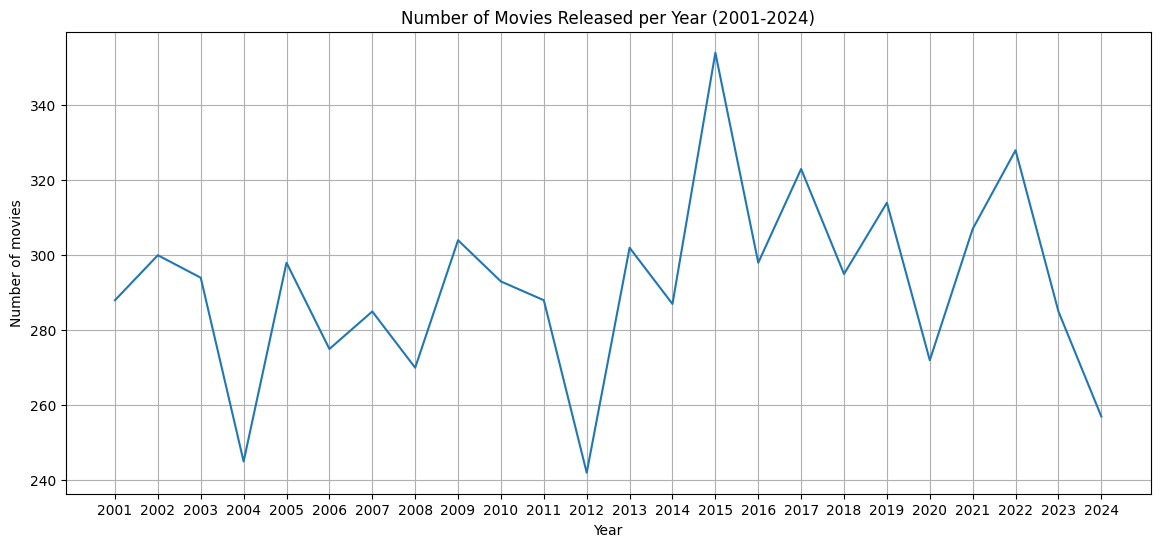

In [15]:
# Count the number of movies per year
movies_per_year = movies['year'].value_counts().sort_index()


# Plot the number of movies per year
plt.figure(figsize=(14, 6))
plt.plot(movies_per_year)
plt.xticks(np.arange(2001, 2025, 1))
plt.xlabel('Year')
plt.ylabel('Number of movies')
plt.title('Number of Movies Released per Year (2001-2024)')
plt.grid()
plt.show()

### What is the relationship between number of votes and the rating of the movie?
There are some considerable outliers that are skewing the distribution of the data. Before removing these outliers, there is very little correlation between average rating and number of votes (R^2 = 0.002). Even after removing the outliers, there is no significant correlation between average rating and number of votes.

But what about from the year 2024?
Still nothing

In [16]:

import statsmodels.api as sm
import statsmodels.formula.api as smf

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          IMDBavgRating   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     859.2
Date:                Tue, 18 Mar 2025   Prob (F-statistic):          2.95e-178
Time:                        14:44:20   Log-Likelihood:                -10496.
No. Observations:                7004   AIC:                         2.100e+04
Df Residuals:                    7002   BIC:                         2.101e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.0755      0.014    424.663      0.000       6.047       6.104
numVotes    2.093e-06   7.14e-08     29.313      0.000    1.95e-06    2.23e-06
==============================================================================
Omnibus:                      440.213   Durbin-Watson:                   1.905
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              693.090
Skew:                          -0.513   Prob(JB):                    3.14e-151
Kurtosis:                       4.149   Cond. No.                     2.22e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.22e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

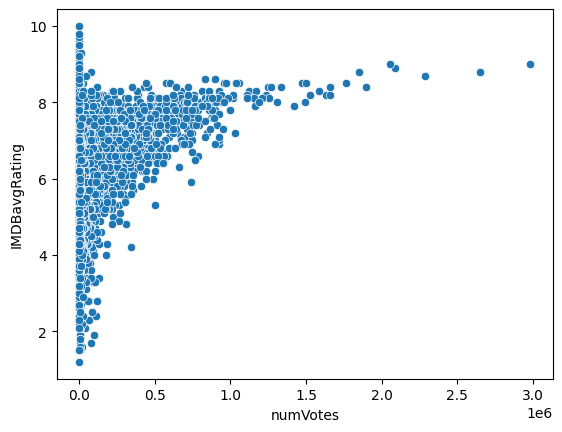

In [17]:
# plot numVote vs averageRating
sns.scatterplot(data=movies,x='numVotes',y='IMDBavgRating')

# create linear model
model0 = smf.ols("IMDBavgRating ~ numVotes", data=movies).fit()
model0.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          IMDBavgRating   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     381.8
Date:                Tue, 18 Mar 2025   Prob (F-statistic):           6.72e-71
Time:                        14:44:20   Log-Likelihood:                -794.66
No. Observations:                 882   AIC:                             1593.
Df Residuals:                     880   BIC:                             1603.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.5528      0.036    180.916      0.000       6.482       6.624
numVotes    1.303e-06   6.67e-08     19.539      0.000    1.17e-06    1.43e-06
==============================================================================
Omnibus:                       43.977   Durbin-Watson:                   1.927
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               52.987
Skew:                          -0.500   Prob(JB):                     3.12e-12
Kurtosis:                       3.666   Cond. No.                     9.79e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.79e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

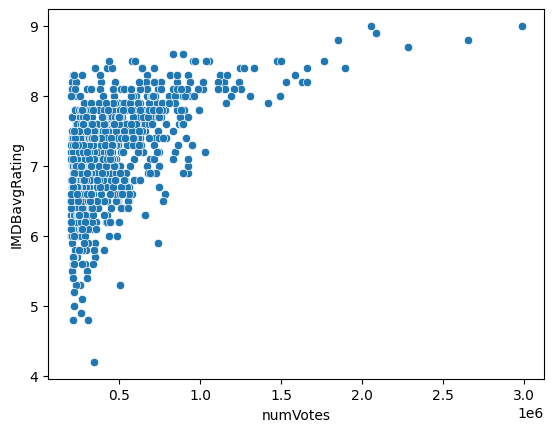

In [18]:
# remove outliers
movies1 = movies[movies['numVotes'] > 200000]
sns.scatterplot(data=movies1,x='numVotes',y='IMDBavgRating')

model1 = smf.ols("IMDBavgRating ~ numVotes", data=movies1).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          IMDBavgRating   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     12.03
Date:                Tue, 18 Mar 2025   Prob (F-statistic):           0.000614
Time:                        14:44:20   Log-Likelihood:                -378.76
No. Observations:                 257   AIC:                             761.5
Df Residuals:                     255   BIC:                             768.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.2717      0.074     85.083      0.000       6.126       6.417
numVotes    3.139e-06   9.05e-07      3.468      0.001    1.36e-06    4.92e-06
==============================================================================
Omnibus:                       14.549   Durbin-Watson:                   1.808
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               17.386
Skew:                          -0.468   Prob(JB):                     0.000168
Kurtosis:                       3.864   Cond. No.                     9.07e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.07e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

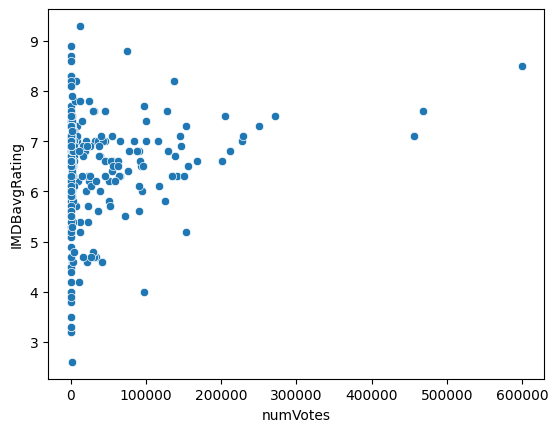

In [19]:
movies_2024 = movies[movies['year'] == 2024]

# plot numVote vs averageRating
sns.scatterplot(data=movies_2024,x='numVotes',y='IMDBavgRating')

# create linear model
model = smf.ols("IMDBavgRating ~ numVotes", data=movies_2024).fit()
model.summary()

### What does the distribution look like for high, medium, and low rated movies? How many votes do each category of movie get?
The number of mediumm rated movies decreased in 2024. During all years there are more medium rated movies than high rated movies. In 2024 the gap decreases significantly. Did directors stop making decent movies? Let's look at the ratings per genre to help us understand.


rating_category  Low  Medium  High
year                              
2001               8     216    64
2002              14     214    72
2003              11     195    88
2004               7     173    65
2005              17     211    70
2006              11     190    74
2007              10     192    83
2008              18     185    67
2009              17     210    77
2010              15     212    66
2011              17     202    69
2012              10     177    55
2013              15     197    90
2014              13     191    83
2015              12     255    87
2016              16     207    75
2017              15     220    88
2018              15     212    68
2019              11     231    72
2020              19     213    40
2021               8     222    77
2022              15     235    78
2023               6     218    61
2024              10     188    59


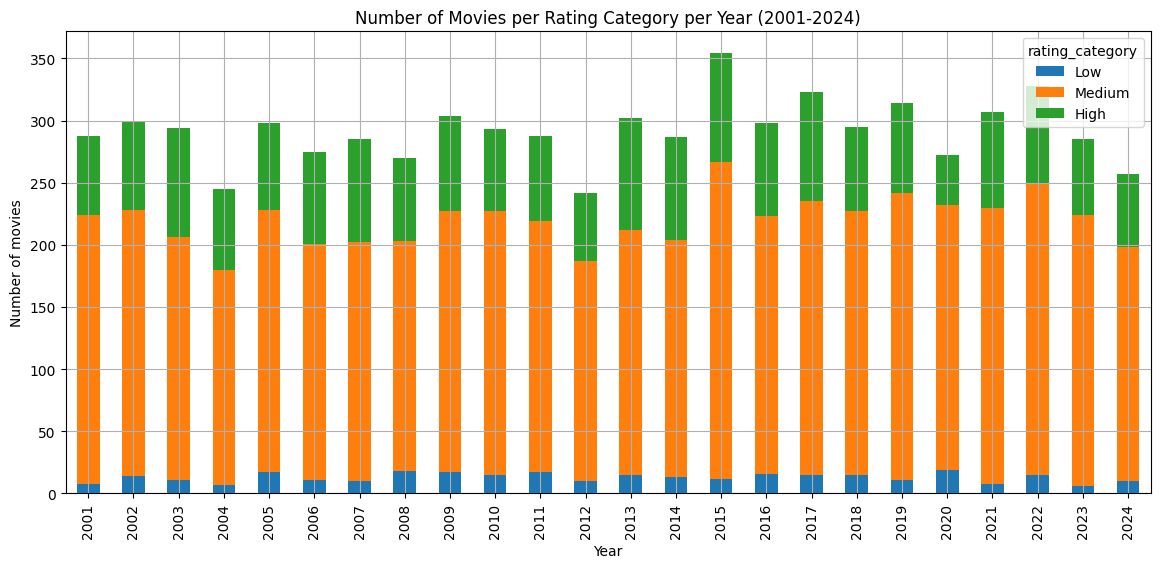

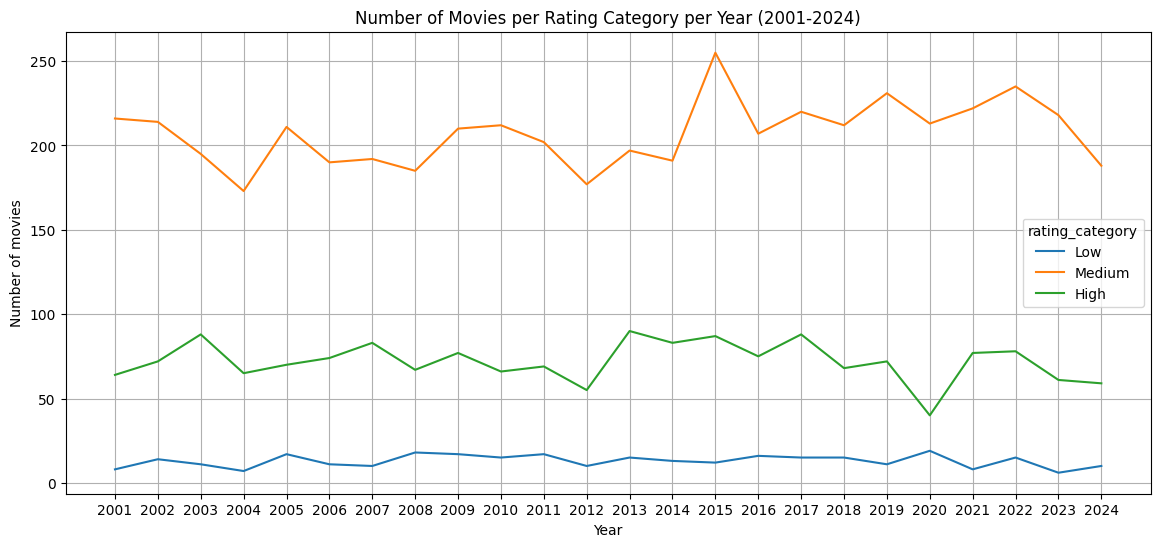

In [20]:
bins = [0, 4, 7, 10]
labels = ['Low', 'Medium', 'High']
movies['rating_category'] = pd.cut(movies['IMDBavgRating'], bins=bins, labels=labels)

# Count the number of movies per rating category per year
movies_per_year = movies.groupby(['year', 'rating_category']).size().unstack().fillna(0)
print(movies_per_year)

# Plot the number of movies per rating category per year
plt.figure(figsize=(14, 6))
movies_per_year.plot(kind='bar', stacked=True, ax=plt.gca())
plt.xlabel('Year')
plt.ylabel('Number of movies')
plt.title('Number of Movies per Rating Category per Year (2001-2024)')
plt.grid()
plt.show()

# plot number of movies per rating category as line plot
plt.figure(figsize=(14, 6))
movies_per_year.plot(kind='line', ax=plt.gca())
plt.xlabel('Year')
plt.xticks(np.arange(2001, 2025, 1))
plt.ylabel('Number of movies')
plt.title('Number of Movies per Rating Category per Year (2001-2024)')
plt.grid()
plt.show()

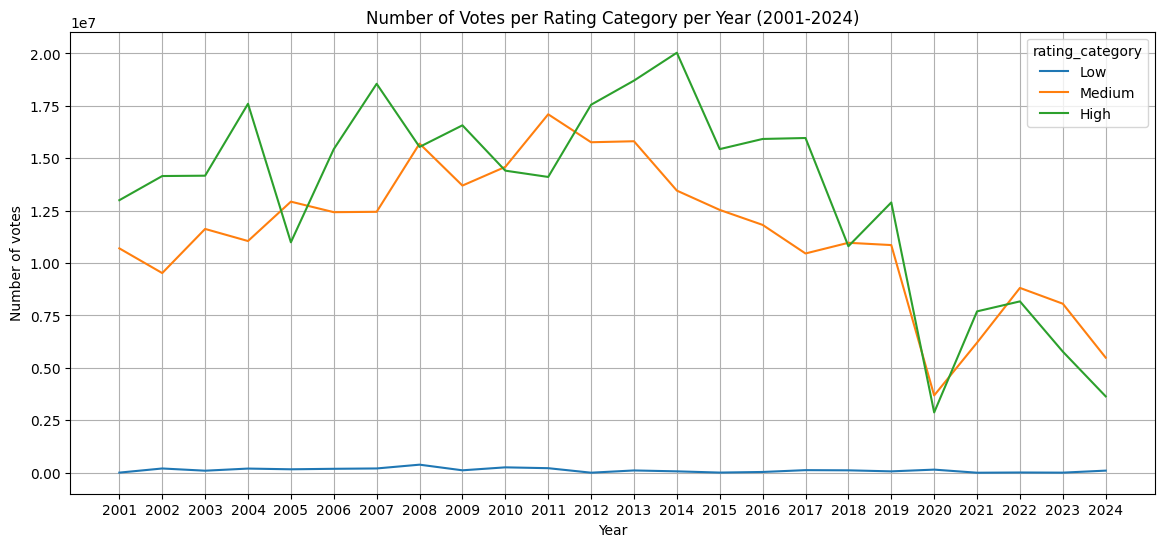

In [21]:
# plot number of votes per rating category as a line plot
votes_per_year = movies.groupby(['year', 'rating_category'])['numVotes'].sum().unstack().fillna(0)
plt.figure(figsize=(14, 6))
votes_per_year.plot(kind='line', ax=plt.gca())
plt.xlabel('Year')
plt.ylabel('Number of votes')
plt.xticks(np.arange(2001, 2025, 1))
plt.title('Number of Votes per Rating Category per Year (2001-2024)')
plt.grid()
plt.show()

In [22]:
movies.sample(5)

,title,originalTitle,isAdult,runtimeMinutes,genres,IMDBavgRating,numVotes,rank,worldwideGross,domesticGross,domestic%,foreignGross,foreign%,year,originalLang,productionCountries,main_genre,rating_category
6346,Split,Suepeullit,0,123,"Action,Drama,Sport",6.6,292,34,278454358.0,138291365.0,49.7,140162993.0,50.3,2017,en,United States of America,Action,Medium
5067,Perfect Days,Perfect Days,0,124,Drama,7.9,77221,117,25637623.0,3766668.0,14.7,21870955.0,85.3,2023,ja,"Germany, Japan",Drama,High
3329,Peppermint,Peppermint,0,82,Drama,8.4,21,118,53918723.0,35418723.0,65.7,18500000.0,34.3,2018,en,"China, United States of America",Drama,High
476,Hero,Ying xiong,0,107,"Action,Adventure,Drama",7.9,190079,74,76089199.0,0.0,0.0,76089199.0,100.0,2007,ja,Japan,Action,High
3371,Tarot,Tarot,0,105,"Drama,Fantasy,Horror",6.3,83,56,49256239.0,18771004.0,38.1,30485235.0,61.9,2024,en,United States of America,Drama,Medium


In [23]:
movies.sort_values(by='numVotes', ascending=False)

,title,originalTitle,isAdult,runtimeMinutes,genres,IMDBavgRating,numVotes,rank,worldwideGross,domesticGross,domestic%,foreignGross,foreign%,year,originalLang,productionCountries,main_genre,rating_category
1521,The Dark Knight,The Dark Knight,0,152,"Action,Crime,Drama",9.0,2985446,1,1.003845e+09,533345358.0,53.1,470500000.0,46.9,2008,en,"United Kingdom, United States of America",Action,High
3192,Inception,Inception,0,148,"Action,Adventure,Sci-Fi",8.8,2653044,4,8.282587e+08,292576195.0,35.3,535682500.0,64.7,2010,en,"United Kingdom, United States of America",Action,High
1811,Interstellar,Interstellar,0,169,"Adventure,Drama,Sci-Fi",8.7,2284961,10,6.810704e+08,188020017.0,27.6,493050380.0,72.4,2014,en,"United Kingdom, United States of America",Adventure,High
6,The Lord of the Rings: The Fellowship of the Ring,The Lord of the Rings: The Fellowship of the Ring,0,178,"Adventure,Drama,Fantasy",8.9,2086193,2,8.683854e+08,313364114.0,36.1,555021246.0,63.9,2001,en,"New Zealand, United States of America",Adventure,High
43,The Lord of the Rings: The Return of the King,The Lord of the Rings: The Return of the King,0,201,"Adventure,Drama,Fantasy",9.0,2057150,1,1.118887e+09,377027325.0,33.7,741859899.0,66.3,2003,en,"New Zealand, United States of America",Adventure,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6860,Identity,Identity,0,99,Mystery,7.6,5,61,9.025954e+07,52159536.0,57.8,38100000.0,42.2,2003,en,United States of America,Mystery,High
5395,The Last Wish,The Last Wish,0,97,Drama,6.0,5,136,3.975629e+07,0.0,0.0,39756292.0,100.0,2019,zh,China,Drama,Medium
5661,Together,Razem,0,50,Documentary,6.8,5,164,1.468717e+07,1151941.0,7.8,13535226.0,92.2,2003,sv,"Denmark, Italy, Norway, Sweden",Documentary,Medium
5660,Together,Razem,0,50,Documentary,6.8,5,151,1.457223e+07,1034829.0,7.1,13537400.0,92.9,2001,sv,"Denmark, Italy, Norway, Sweden",Documentary,Medium


In [24]:
# Filter movies with more than 200k votes
movies_200k_votes = movies[movies['numVotes'] >= 200000]

In [25]:
# Group by release year and calculate the average rating
average_ratings_per_year = movies_200k_votes.groupby('year')['IMDBavgRating'].mean().reset_index()

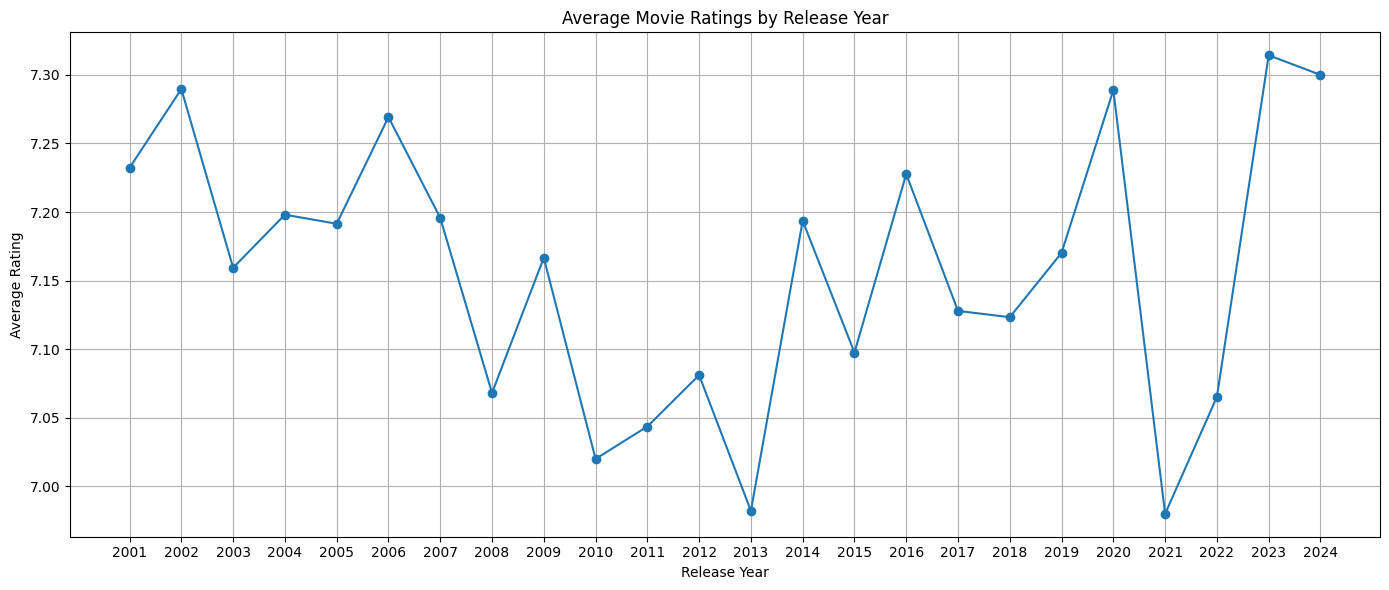

In [26]:
# Plotting the average ratings over the years
plt.figure(figsize=(14, 6))
plt.plot(average_ratings_per_year['year'], average_ratings_per_year['IMDBavgRating'], marker='o')
plt.title('Average Movie Ratings by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.xticks(average_ratings_per_year['year'])  # Annotate each year on the x-axis
plt.tight_layout()
plt.show()

In [27]:
# Group by genres and split multiple genres into separate rows
df_genres = movies_200k_votes.assign(genres=movies_200k_votes['genres'].str.split(',')).explode('genres')

In [28]:
# Group by genre and release year and calculate the average rating
average_ratings_by_genre_year = (df_genres.groupby(['genres', 'year'])['IMDBavgRating'].mean().reset_index())

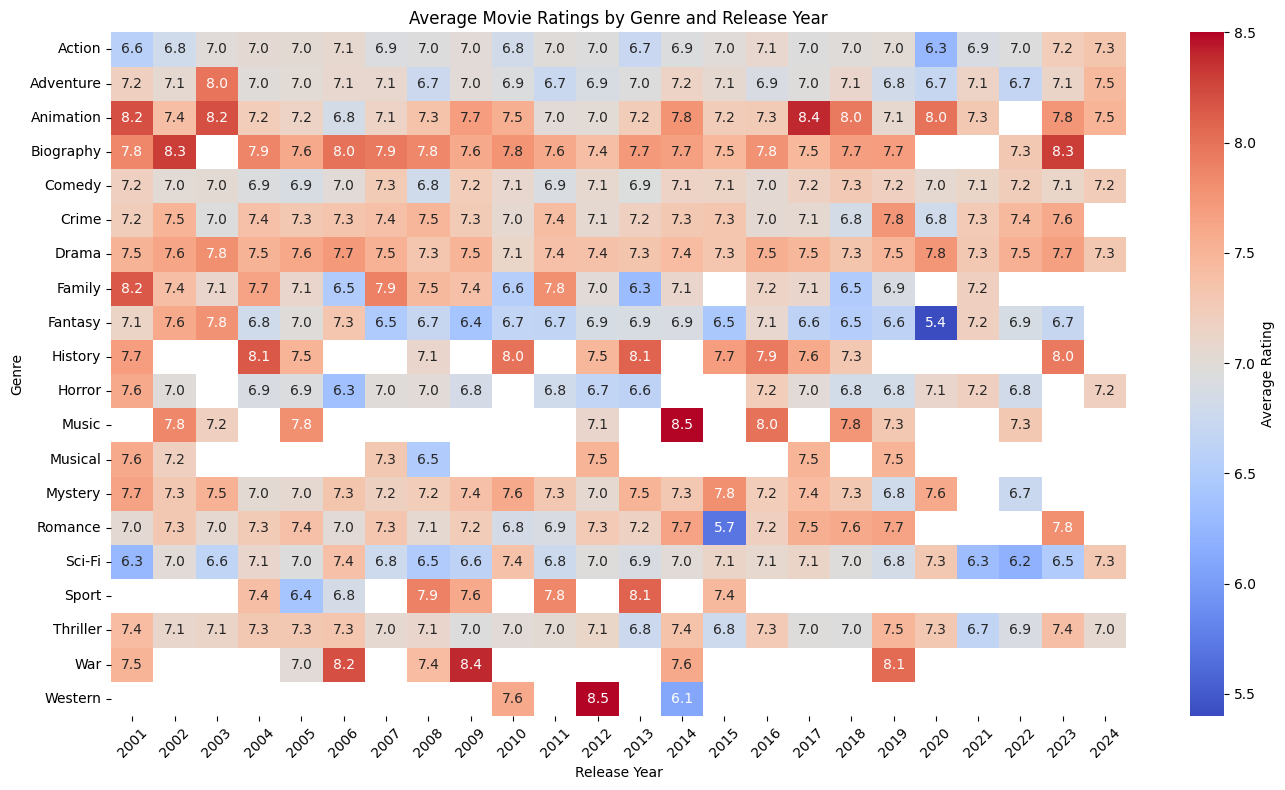

In [29]:
# Pivot the data for heatmap
heatmap_data = average_ratings_by_genre_year.pivot(index='genres', columns='year', values='IMDBavgRating')

# Create the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='coolwarm', cbar_kws={'label': 'Average Rating'})
plt.title('Average Movie Ratings by Genre and Release Year')
plt.xlabel('Release Year')
plt.ylabel('Genre')
plt.xticks(rotation=45)  # Rotate x-axis for better readability
plt.yticks(rotation=0)   # Keep y-axis labels horizontal
plt.tight_layout()
plt.show()

# Part 2

#### Descriptive Statistics
Provide a comprehensive summary of your combined dataset using descriptive statistics. This should include means, medians, modes, ranges, variance, and standard deviations for the relevant features of your data.  The descriptive statistics should inform your guiding questions that you developed in Part I of the project, rather than merely providing an overview of your data.  Interpret these results to draw preliminary conclusions about the data.


In [62]:
# Filter movies with more than 200k votes
movies_200k_votes = movies[movies['numVotes'] >= 200000]

In [53]:
# Columns to include in the new DataFrame
columns_to_select = ['title', 'year', 'main_genre', 'worldwideGross', 'domesticGross', 'domestic%', 'foreignGross', 'foreign%']

# Create a new DataFrame by selecting the specified columns
genre_income = movies_200k_votes[columns_to_select]

# Display the new DataFrame
print(genre_income.columns)

Index(['title', 'year', 'main_genre', 'worldwideGross', 'domesticGross',
       'domestic%', 'foreignGross', 'foreign%'],
      dtype='object')


In [55]:

# Group by 'main_genre' without aggregation
genre_grouped = genre_income.groupby('main_genre')

# Iterate over each group
for genre, group_data in genre_grouped:
    print(f"\nGenre: {genre}")

    # Display the first 5 rows of each group
    print(genre_grouped.head(5))




Genre: Action
                                                  title  year main_genre  \
2                                        Fantastic Four  2005     Action   
3                                        Fantastic Four  2015     Action   
6     The Lord of the Rings: The Fellowship of the Ring  2001  Adventure   
7                                         Resident Evil  2002     Action   
10                                      Men in Black II  2002     Action   
11                                         Corpse Bride  2005  Animation   
12         Star Wars: Episode II - Attack of the Clones  2002     Action   
15                                                Shrek  2001  Adventure   
21                                         Training Day  2001      Crime   
40                                     Mulholland Drive  2001      Drama   
43        The Lord of the Rings: The Return of the King  2003  Adventure   
44                The Lord of the Rings: The Two Towers  2002  Adventure 

In [52]:
# # List to store DataFrames
# frames = []

# # Iterate over each group
# for genre, group_data in genre_grouped:
#     # Select numeric columns
#     numeric_data = group_data.select_dtypes(include=np.number)

#     # Calculate statistics
#     stats = {
#         'Mean': numeric_data.mean().round(1),
#         'Median': numeric_data.median().round(1),
#         'Mode': numeric_data.mode().iloc[0].round(1),
#         'Range': (numeric_data.max() - numeric_data.min()).round(1),
#         'Variance': numeric_data.var().round(1),
#         'Standard Deviation': numeric_data.std().round(1)
#     }

#     # Create a DataFrame for the stats and transpose it
#     stats_df = pd.DataFrame(stats).transpose()

#     # Add a 'metric' column
#     stats_df['metric'] = stats_df.index

#     # Add 'genre' column
#     stats_df['genre'] = genre

#     # Rearrange columns, so 'metric' and 'genre' come first
#     stats_df = stats_df[['metric', 'genre'] + [col for col in stats_df.columns if col not in ['metric', 'genre']]]

#     # Append to list of frames
#     frames.append(stats_df)

# # Concatenate all the genre DataFrames
# genre_stats_df = pd.concat(frames, ignore_index=True)

# # Display the result DataFrame
# print(genre_stats_df.head(10))

def print_group_stats(df):
    '''Print the grouped statistics for each genre'''
    for column in df.select_dtypes(include=np.number).columns:
        print(f"\n{column} Statistics:")
        print(df.groupby('main_genre')[column].describe().round(1))

print_group_stats(genre_income)


year Statistics:
            count    mean  std     min     25%     50%     75%     max
main_genre                                                            
Action      399.0  2012.4  5.9  2001.0  2008.0  2013.0  2017.0  2024.0
Adventure   112.0  2010.2  5.7  2001.0  2005.8  2010.0  2014.0  2024.0
Animation     6.0  2013.2  5.7  2005.0  2009.8  2014.0  2016.0  2021.0
Biography    51.0  2011.8  5.7  2001.0  2007.5  2013.0  2016.0  2023.0
Comedy      116.0  2009.2  5.2  2001.0  2004.8  2009.0  2012.0  2024.0
Crime        55.0  2009.1  5.7  2001.0  2005.0  2007.0  2013.0  2023.0
Drama       104.0  2011.3  5.9  2001.0  2006.0  2011.0  2016.0  2024.0
Fantasy       2.0  2004.0  4.2  2001.0  2002.5  2004.0  2005.5  2007.0
Horror       31.0  2012.9  6.6  2001.0  2007.0  2013.0  2017.0  2024.0
Mystery       4.0  2006.2  2.5  2003.0  2005.2  2006.5  2007.5  2009.0
Sci-Fi        2.0  2009.0  2.8  2007.0  2008.0  2009.0  2010.0  2011.0

worldwideGross Statistics:
            count         mean 

## Inferential Statistics
Conduct appropriate hypothesis tests to investigate if there are significant differences or correlations within your data.  This might involve regression analysis, ANOVA, and/or chi-squared tests.

Clearly state your null and alternative hypotheses, choose an appropriate significance level, and discuss your findings. Make sure to justify the choice of your tests.

ANOVA Results:
                      sum_sq     df         F        PR(>F)
C(main_genre)  2.069096e+19   10.0  20.38187  3.514854e-34
Residual       8.842085e+19  871.0       NaN           NaN


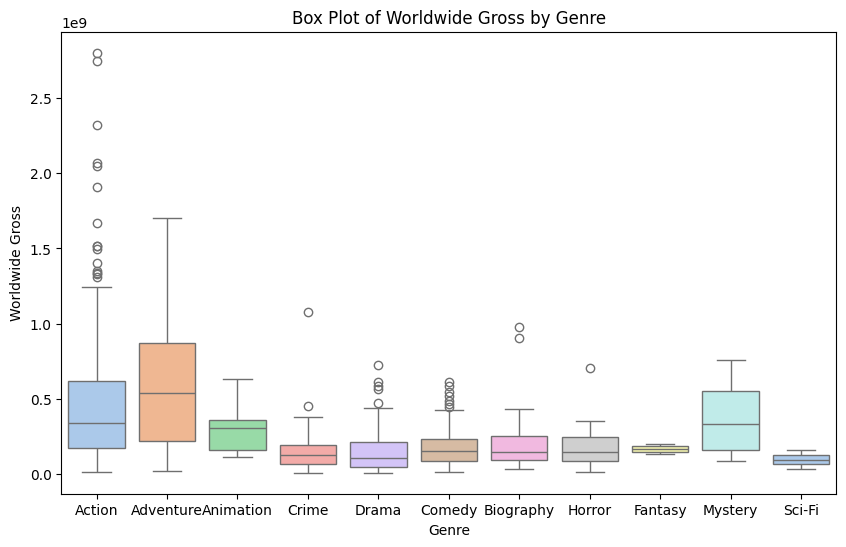

In [47]:
from statsmodels.formula.api import ols
from scipy.stats import pearsonr

### ANOVA: Test if `worldwideGross` differs significantly across `main_genre`
anova_model = ols('worldwideGross ~ C(main_genre)', data=genre_income).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

print("ANOVA Results:\n", anova_table)

# Box Plot of Foreign Gross by Genre
plt.figure(figsize=(10, 6))
sns.boxplot(data=genre_income, x='main_genre', y='worldwideGross', palette='pastel')
plt.title('Box Plot of Worldwide Gross by Genre')
plt.xlabel('Genre')
plt.ylabel('Worldwide Gross')
plt.show()

## Interpretation

- Action has many outliers for worldwide gross
- Mystery has a higher median than a lot of other genres

## Chi-Square Test

<Figure size 1000x600 with 0 Axes>

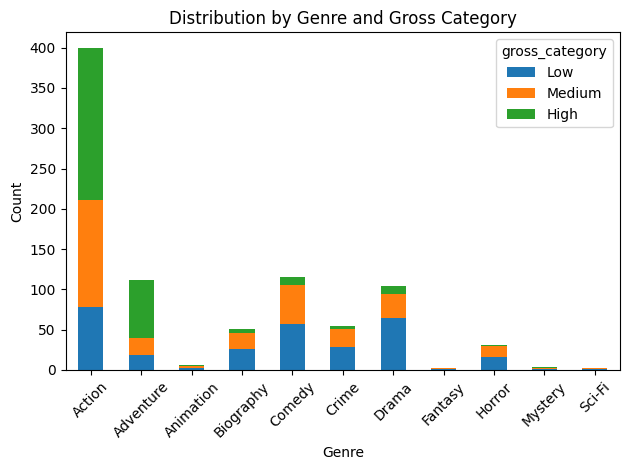

In [56]:
# Bin worldwideGross into 3 categories (Low, Medium, High)
genre_income['gross_category'] = pd.qcut(genre_income['worldwideGross'], q=3, labels=['Low', 'Medium', 'High'])

# Create a contingency table that counts the gross_category for each production country
contingency_table = pd.crosstab(genre_income['main_genre'], genre_income['gross_category'])



plt.figure(figsize=(10,6))
contingency_table.plot(kind='bar', stacked=True)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Distribution by Genre and Gross Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
print(contingency_table)

gross_category  Low  Medium  High
main_genre                       
Action           78     133   188
Adventure        19      21    72
Animation         2       3     1
Biography        26      20     5
Comedy           57      48    11
Crime            29      22     4
Drama            64      30    10
Fantasy           1       1     0
Horror           16      14     1
Mystery           1       1     2
Sci-Fi            1       1     0


## Interpretation

- It is seen that Mystery only has 4 moives, and 2 of them are in the high catagory which is why the median was higher than other genres
- The majority of movies that are high grossing are Action genre

## Graphical Analysis

Create various types of plots to visualize relationships within your data. Use histograms, bar charts, scatter plots, box plots, and any other suitable graphical representations you've learned.

Be sure to use appropriate titles, labels, and legends to make your plots readable and informative.

Interpret the graphical representations to uncover patterns, trends, and outliers.


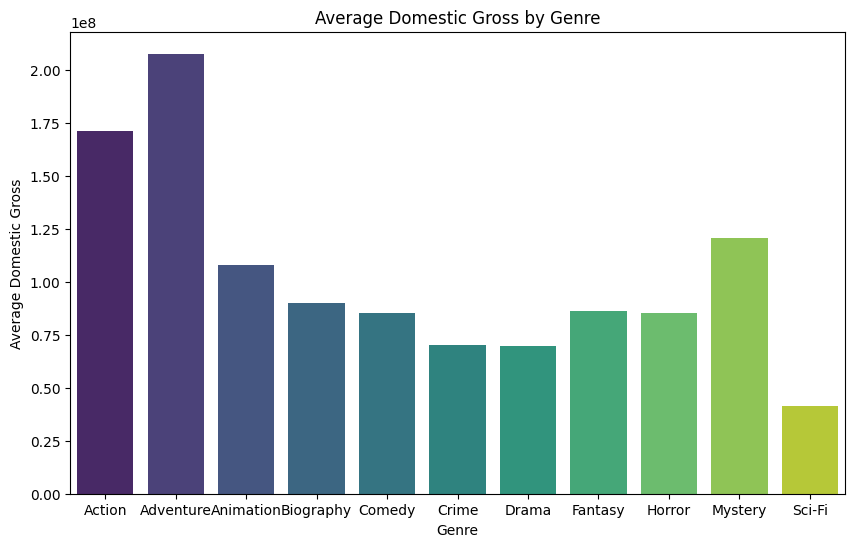

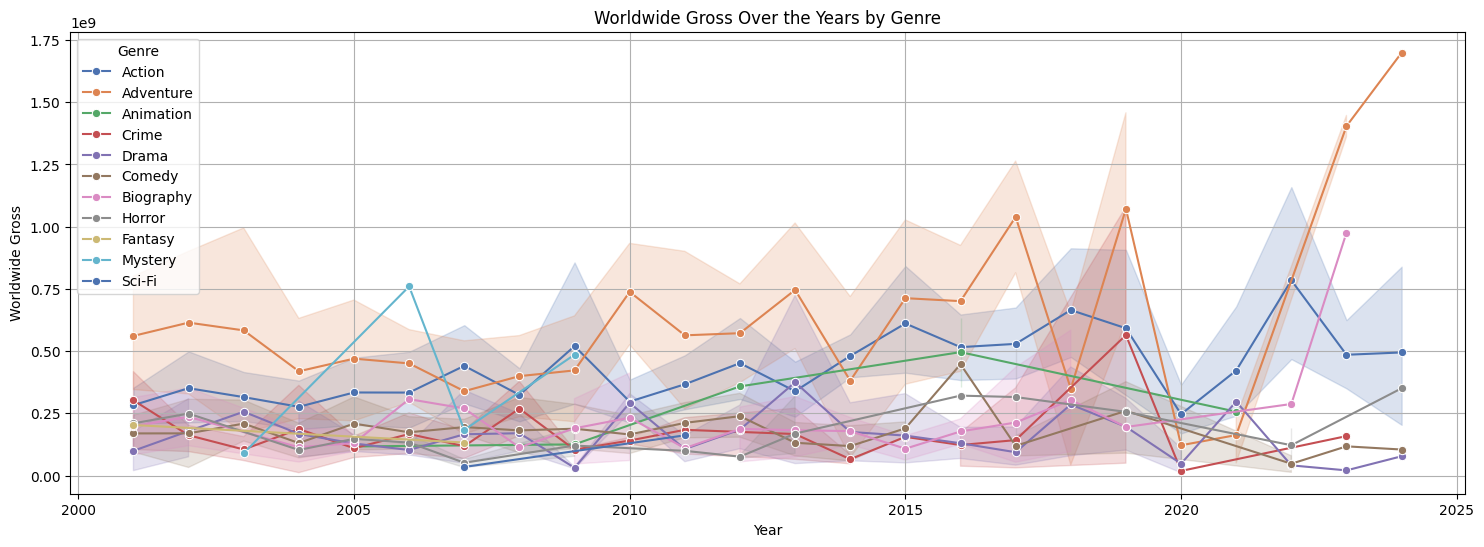

In [61]:
# Bar Chart of Average Domestic Gross by Genre
avg_domestic_gross_by_genre = genre_income.groupby('main_genre')['domesticGross'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_domestic_gross_by_genre, x='main_genre', y='domesticGross', palette='viridis')
plt.title('Average Domestic Gross by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Domestic Gross')
plt.show()


# Line Plot of Worldwide Gross Over the Years for Each Genre
plt.figure(figsize=(18, 6))
sns.lineplot(data=genre_income, x='year', y='worldwideGross', hue='main_genre', marker='o', palette='deep')
plt.title('Worldwide Gross Over the Years by Genre')
plt.xlabel('Year')
plt.ylabel('Worldwide Gross')
plt.legend(title='Genre')
plt.grid(True)
plt.show()

## Interpretation

- The Adventrue genre has a higher mean than other genres
- It is clearly seen with the Line Plot the effect to worldwide gross by the COVID-19 pandemic

## Comparative Analysis

Compare and contrast different subsets of your data. This can include comparisons over time, across different categories, or any other relevant segmentation.  Note that for some projects, the nature of this comparative analysis will be obvious.  For others, you will need to think about how you might subset your data.

Discuss any notable similarities or differences you have identified.


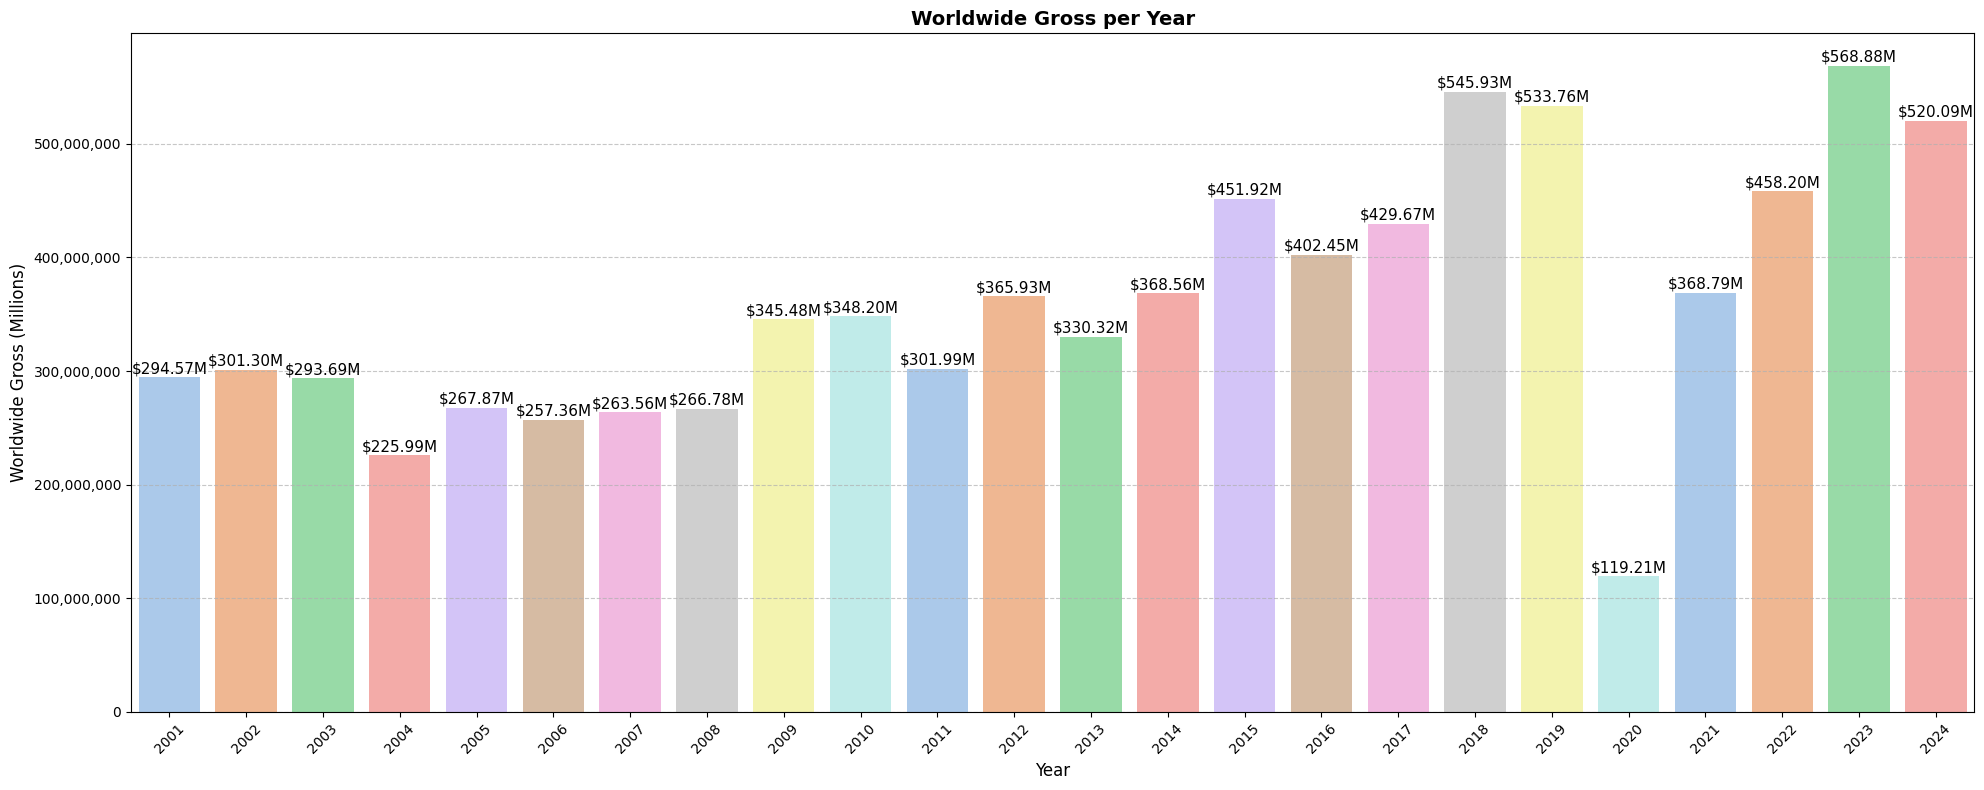

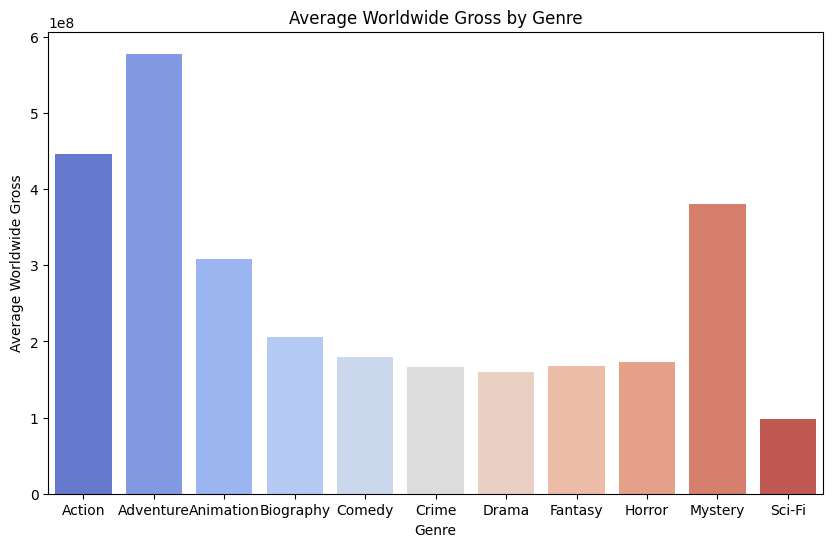

In [44]:
# Enhanced Bar Plot with Labels in Millions
plt.figure(figsize=(20, 8))
ax = sns.barplot(data=genre_income, x='year', y='worldwideGross', ci=None, palette='pastel')
plt.title('Worldwide Gross per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Worldwide Gross (Millions)', fontsize=12)
plt.xticks(rotation=45)

# Add data labels in millions
for p in ax.patches:
    ax.annotate(f"${p.get_height()/1e6:,.2f}M",  # Converts to millions and formats
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 3),
                textcoords='offset points')

# Use commas in Y-axis labels for readability
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Adding gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Comparison 2: Across Genres
# Compare average worldwide gross by genre
avg_worldwide_gross_by_genre = genre_income.groupby('main_genre')['worldwideGross'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_worldwide_gross_by_genre, x='main_genre', y='worldwideGross', palette='coolwarm')
plt.title('Average Worldwide Gross by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Worldwide Gross')
plt.show()


## Interpretation

- It took 3 year for the worldwide gross to get back to Pre COVID-19 pandemic
- The mean for Adventure worldwide gross is also the highest for genres

## Multivariate Analysis

Perform multivariate analysis to understand the relationships among three or more variables in your dataset.

Use techniques like cross-tabulation, pivot tables, and multivariate graphs.


Pivot Table:
year                2001          2002          2003          2004  \
main_genre                                                           
Action      2.829993e+08  3.512025e+08  3.153443e+08  2.764721e+08   
Adventure   5.612269e+08  6.145990e+08  5.833910e+08  4.191490e+08   
Animation            NaN           NaN           NaN           NaN   
Biography   1.984123e+08  2.360934e+08           NaN  1.141086e+08   
Comedy      1.695670e+08  1.697890e+08  2.090516e+08  1.307768e+08   
Crime       3.024286e+08  1.622019e+08  1.049534e+08  1.872972e+08   
Drama       9.966539e+07  1.790105e+08  2.566975e+08  1.675496e+08   
Fantasy     2.033883e+08           NaN           NaN           NaN   
Horror      2.099470e+08  2.493489e+08           NaN  1.030963e+08   
Mystery              NaN           NaN  9.025954e+07           NaN   
Sci-Fi               NaN           NaN           NaN           NaN   

year                2005          2006          2007          2008  \
main_g

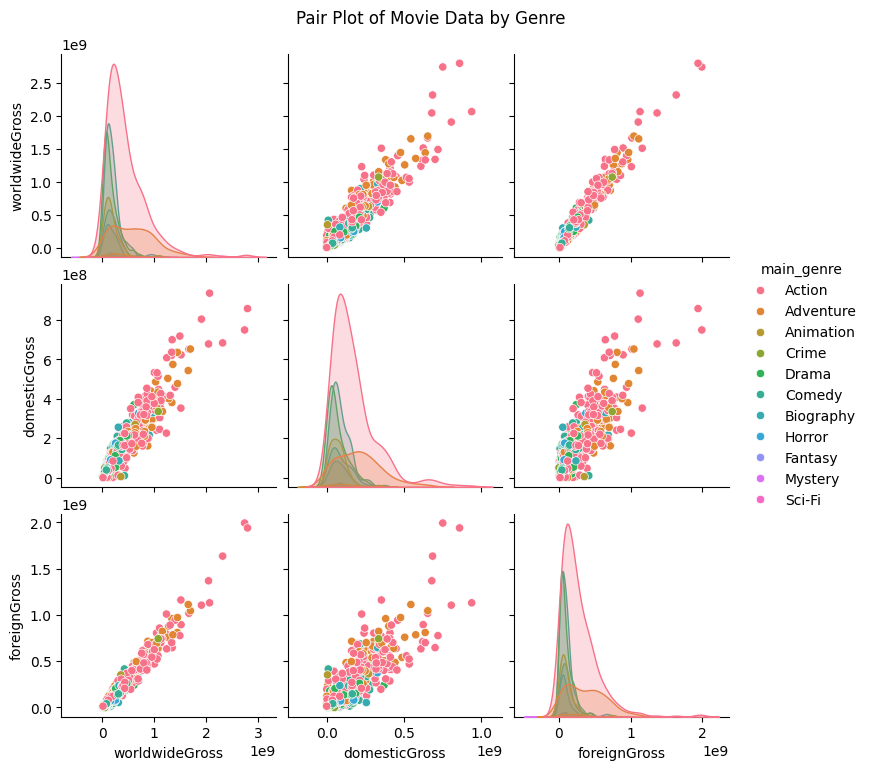

In [60]:
### Cross-tabulation with Pivot Table
# Pivot table for average worldwide gross by genre and year
pivot_table = pd.pivot_table(genre_income, values='worldwideGross', index='main_genre', columns='year', aggfunc='mean')
print("Pivot Table:")
print(pivot_table)

### Multivariate Graph: Pair Plot

new_df = genre_income[['worldwideGross', 'domesticGross', 'foreignGross', 'main_genre']]

# Pair plot to explore relationships between numeric variables
sns.pairplot(new_df, hue='main_genre')
plt.suptitle('Pair Plot of Movie Data by Genre', y=1.02)
plt.show()


## Interpretation

- As foreign gross increases worldwide gross increases
- Domestic gross is correlated with foreign gross

In [ ]:
genre_income.head(5)

,title,year,main_genre,worldwideGross,domesticGross,domestic%,foreignGross,foreign%
2,Fantastic Four,2005,Action,333535934.0,154696080.0,46.4,178839854.0,53.6
3,Fantastic Four,2015,Action,167882881.0,56117548.0,33.4,111765333.0,66.6
6,The Lord of the Rings: The Fellowship of the Ring,2001,Adventure,868385360.0,313364114.0,36.1,555021246.0,63.9
7,Resident Evil,2002,Action,102984862.0,40119709.0,39.0,62865153.0,61.0
10,Men in Black II,2002,Action,441818803.0,190418803.0,43.1,251400000.0,56.9


In [ ]:
# write to csv
movies.to_csv('movies.csv', index=False)